# Mapping the Phase Diagram of the ANNNI Model under Depolarizing Noise

The clean diagram is the exact ground state of the ANNNI Hamiltonian. The noisy diagrams are the same Hamiltonian minimized with a variational quantum eigensolver, with a depolarizing channel after every CNOT. Both use the same order parameters, so the boundaries can be compared on one color scale.

Images written by this notebook:

- `figures/phase_diagram_p0.00.png` — exact, p = 0
- `figures/phase_diagram_p0.01.png` — VQE, p = 0.01
- `figures/phase_diagram_p0.05.png` — VQE, p = 0.05


## 1. Setup

$$H = -\sum_i Z_i Z_{i+1} + \kappa \sum_i Z_i Z_{i+2} - h \sum_i X_i$$

N = 8 is the baseline size in the brief. The grid is 15×15 over κ ∈ [0, 1] and h ∈ [0, 2], which is the minimum resolution the rubric accepts. `starter_kit/scan.py` does the sweep: exact diagonalization at p = 0, and a warm-started noisy VQE at p = 0.01 and p = 0.05. Section 4 checks that same VQE at p = 0 against the exact energy, so the boundary shifts later can be read against a known ansatz error.


In [3]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-scientific-track")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "Scientific Track" / "starter_kit").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "Scientific Track"
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

from starter_kit import (
    bkt_transition,
    exact_ground_state,
    ising_transition,
    kt_transition,
    scan,
)

N = 8
GRID = 15
LAYERS = 3
FIRST_STEPS = 60
WARM_STEPS = 10
STEPSIZE = 0.1
SEED = 0
WORKERS = 4
VQE_NOISE = (0.01, 0.05)

kappas = np.linspace(0.0, 1.0, GRID)
hs = np.linspace(0.0, 2.0, GRID)

FIG_DIR = NOTEBOOK_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)
RESULT_DIR = NOTEBOOK_DIR / "results"
RESULT_DIR.mkdir(exist_ok=True)

print(f"PennyLane {qml.__version__}")
print(f"N={N}, grid={GRID}x{GRID}, layers={LAYERS}, first_steps={FIRST_STEPS}, warm_steps={WARM_STEPS}, workers={WORKERS}")


PennyLane 0.45.1
N=8, grid=15x15, layers=3, first_steps=60, warm_steps=10, workers=4


## 2. Analytical boundaries

The overlay curves are the infinite-volume lines from the PennyLane ANNNI demo. At N = 8 they are a guide. For κ > 0.5 the floating phase lies between the BKT line and the KT line; this system size does not resolve that sliver.


In [5]:
kappa_ref = np.linspace(0.0, 1.0, 500)
h_ising = ising_transition(kappa_ref)
h_kt = kt_transition(kappa_ref)
h_bkt = bkt_transition(kappa_ref)

def add_boundaries(ax):
    ax.plot(kappa_ref, h_ising, color="white", ls="--", lw=1.5, label="Ising (ferro-para)")
    ax.plot(kappa_ref, h_kt, color="white", ls=":", lw=1.5, label="KT (floating-para)")
    ax.plot(kappa_ref, h_bkt, color="white", ls="-.", lw=1.5, label="BKT (antiphase-floating)")
    ax.axvline(0.5, color="white", lw=0.8, alpha=0.5, ls="--")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.4)


## 3. Clean phase diagram, from exact diagonalization

There is no circuit at p = 0, so the ground state is the lowest eigenvector of H.

- ⟨Zᵢ Zᵢ₊₁⟩ is large in the ferromagnet (κ < 0.5, low h).
- S(π/2) is large in the antiphase (κ > 0.5, low h).
- ⟨X⟩ is large in the paramagnet (high h).

Color limits are fixed from this exact diagram and reused for every noisy panel, so a dimmer panel means the order got smaller.


In [7]:
clean_path = RESULT_DIR / f"exact_N{N}_G{GRID}.npz"
if clean_path.exists():
    clean = dict(np.load(clean_path))
    print(f"Loaded {clean_path.name}")
else:
    clean = scan.run_exact_grid_scan(kappas, hs, n_qubits=N)
    np.savez(clean_path, **clean)
    print(f"Saved {clean_path.name}")


Loaded exact_N8_G15.npz


Saved phase_diagram_p0.00.png


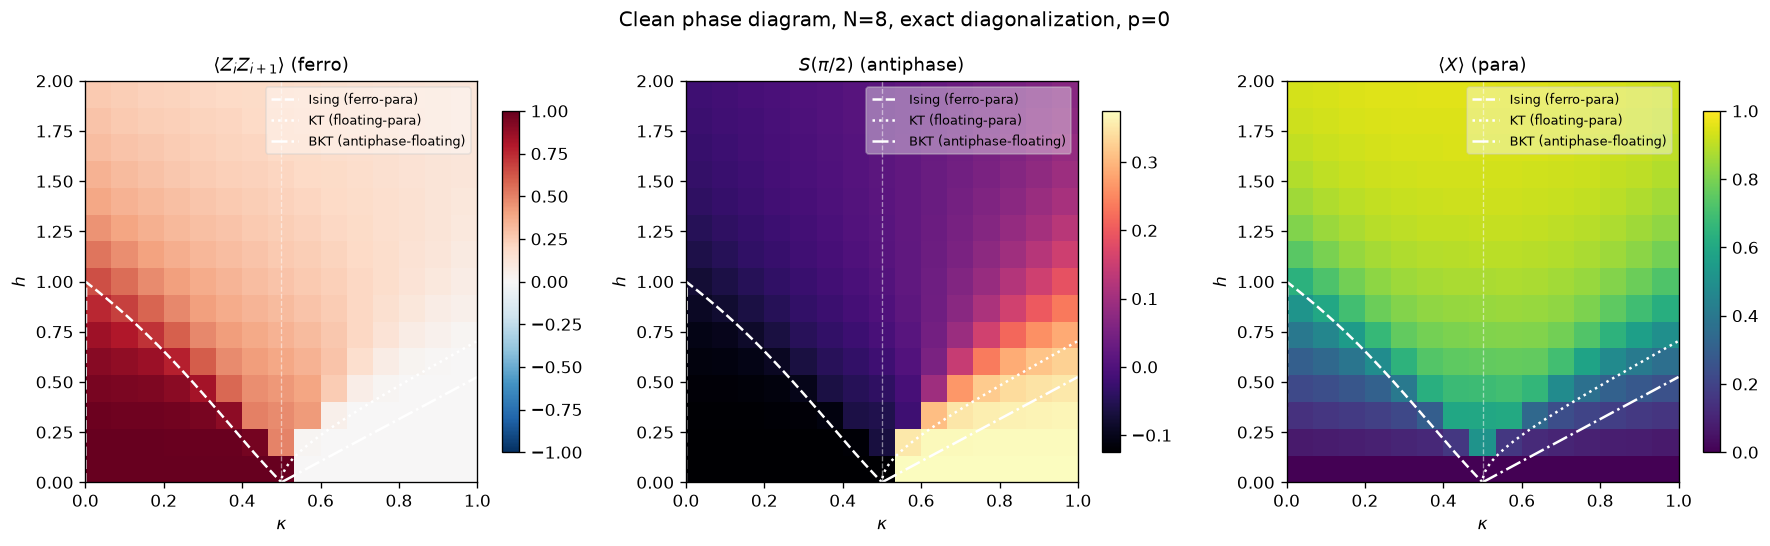

In [8]:
PANELS = [
    ("zz_nearest_mean", r"$\langle Z_i Z_{i+1} \rangle$ (ferro)", "RdBu_r"),
    ("structure_factor_pi2", r"$S(\pi/2)$ (antiphase)", "magma"),
    ("x_mean", r"$\langle X \rangle$ (para)", "viridis"),
]
SCALES = {
    "zz_nearest_mean": (-1.0, 1.0),
    "x_mean": (0.0, 1.0),
    "structure_factor_pi2": (
        float(np.min(clean["structure_factor_pi2"])),
        float(max(float(np.max(clean["structure_factor_pi2"])), 1e-6)),
    ),
}

def plot_phase_diagram(grids, title, outfile):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for ax, (key, panel_title, cmap) in zip(axes, PANELS):
        vmin, vmax = SCALES[key]
        image = ax.imshow(
            grids[key],
            origin="lower",
            aspect="auto",
            extent=[float(kappas.min()), float(kappas.max()), float(hs.min()), float(hs.max())],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xlabel(r"$\kappa$")
        ax.set_ylabel(r"$h$")
        ax.set_title(panel_title, fontsize=11)
        add_boundaries(ax)
        fig.colorbar(image, ax=ax, shrink=0.85)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {outfile.name}")

plot_phase_diagram(
    clean,
    f"Clean phase diagram, N={N}, exact diagonalization, p=0",
    FIG_DIR / "phase_diagram_p0.00.png",
)


## 4. Check the ansatz at p = 0

The VQE uses a 3-layer RY + CNOT ring on `default.mixed`. At p = 0 the channel is absent, so the energy should approach the exact ground-state energy. Whatever gap remains in this table is optimizer error. The noisy diagrams below use the same ansatz and the same step budget.


In [10]:
check_points = [
    (0.2, 0.2, "ferromagnet"),
    (0.8, 0.2, "antiphase"),
    (0.3, 1.5, "paramagnet"),
]

print(f"{'phase':<14} {'exact':>8} {'VQE':>8} {'error':>8} {'ZZ':>8} {'S(pi/2)':>8} {'<X>':>8}")
vqe_errors = []
for kappa, h, phase in check_points:
    exact = exact_ground_state(n_qubits=N, kappa=kappa, h=h, periodic=True)
    vqe = scan.optimize_point(
        kappa, h, 0.0,
        n_qubits=N, layers=LAYERS, steps=FIRST_STEPS, stepsize=STEPSIZE, seed=SEED,
    )
    error = float(vqe["energy"] - exact["ground_energy"])
    vqe_errors.append(error)
    print(
        f"{phase:<14} {exact['ground_energy']:8.3f} {float(vqe['energy']):8.3f} {error:8.3f}"
        f" {vqe['zz_nearest_mean']:8.3f} {vqe['structure_factor_pi2']:8.3f} {vqe['x_mean']:8.3f}"
    )
print(f"Largest energy error at these three points: {max(vqe_errors):.3f}")


phase             exact      VQE    error       ZZ  S(pi/2)      <X>
ferromagnet      -6.501   -6.332    0.169    0.977   -0.121    0.041
antiphase        -6.503   -6.406    0.097    0.001    0.371    0.047
paramagnet      -13.149  -12.986    0.163    0.239   -0.006    0.928
Largest energy error at these three points: 0.169


## 5. Noisy phase diagrams

Each row of fixed h is one warm-started sweep in κ. The first κ is a cold start of `FIRST_STEPS`; every later κ reuses those parameters for `WARM_STEPS` updates. Four rows run at a time, matching the four physical cores.

p = 0.01 is a 1% depolarizing probability on the CNOT target. p = 0.05 is 5%. Color scales are the ones fixed by the exact diagram.


In [12]:
def load_or_run_vqe(p):
    path = RESULT_DIR / f"vqe_p{p:.2f}_N{N}_G{GRID}_L{LAYERS}_s{FIRST_STEPS}_{WARM_STEPS}.npz"
    if path.exists():
        print(f"Loaded {path.name}")
        return dict(np.load(path))
    print(f"Running VQE grid at p={p:.2f}. This is the slow cell.")
    grids = scan.run_noisy_grid_scan(
        kappas,
        hs,
        p,
        n_qubits=N,
        layers=LAYERS,
        first_steps=FIRST_STEPS,
        warm_steps=WARM_STEPS,
        stepsize=STEPSIZE,
        workers=WORKERS,
        seed=SEED,
    )
    np.savez(path, **grids)
    print(f"Saved {path.name}")
    return grids

vqe_grids = {p: load_or_run_vqe(p) for p in VQE_NOISE}


Running VQE grid at p=0.01. This is the slow cell.
Saved vqe_p0.01_N8_G15_L3_s60_10.npz
Running VQE grid at p=0.05. This is the slow cell.
Saved vqe_p0.05_N8_G15_L3_s60_10.npz


Saved phase_diagram_p0.01.png
Saved phase_diagram_p0.05.png


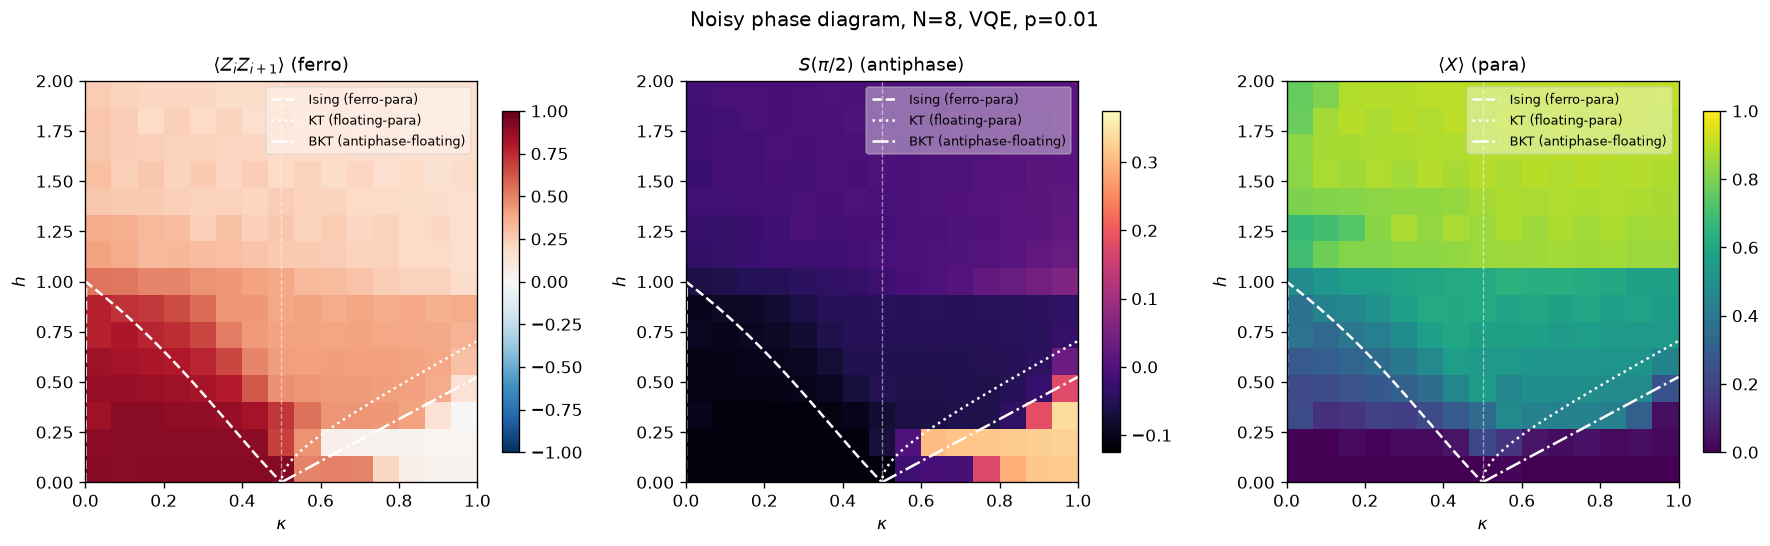

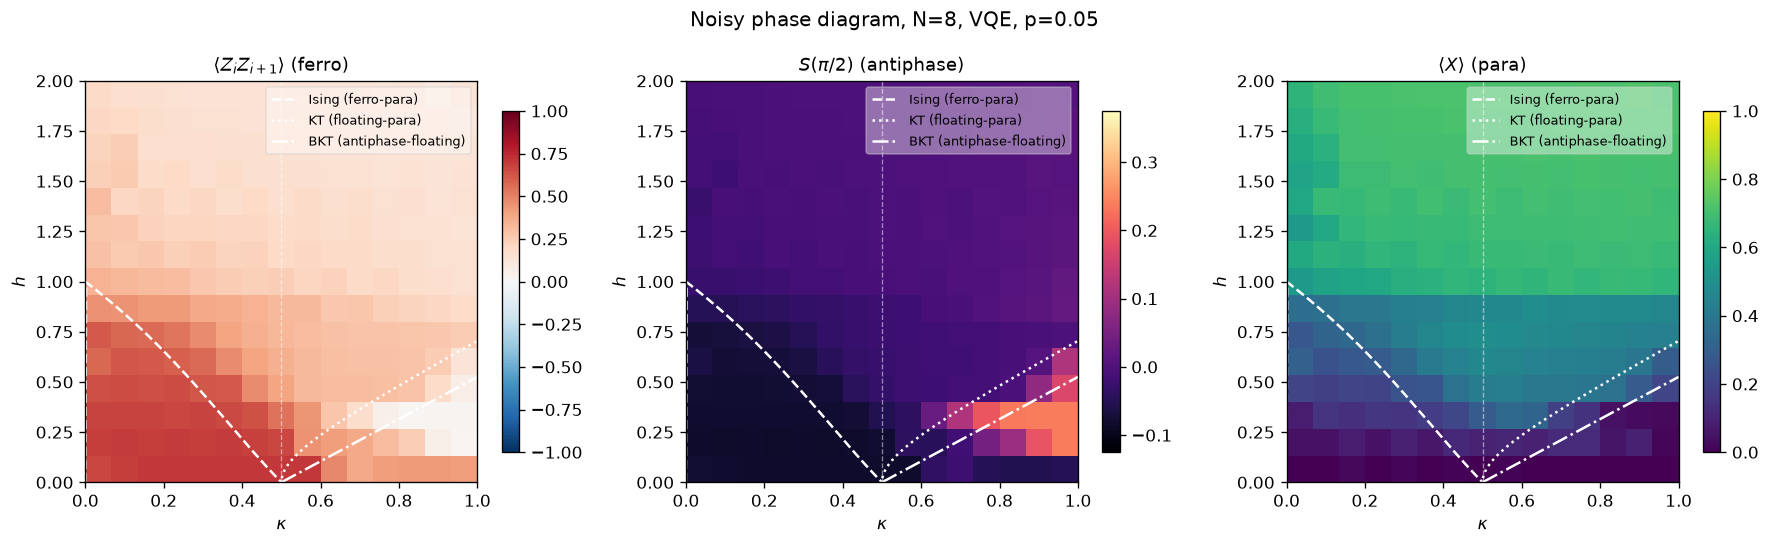

In [13]:
plot_phase_diagram(
    vqe_grids[0.01],
    f"Noisy phase diagram, N={N}, VQE, p=0.01",
    FIG_DIR / "phase_diagram_p0.01.png",
)
plot_phase_diagram(
    vqe_grids[0.05],
    f"Noisy phase diagram, N={N}, VQE, p=0.05",
    FIG_DIR / "phase_diagram_p0.05.png",
)
